# Customer Intelligence System and Clustering on Country Data

## Objective

Developed an end-to-end Customer Intelligence System on Country Data covering:

1. Data Loading & Overview
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Feature Scaling
5. K-Means Clustering
6. DBSCAN Clustering
7. Classification
8. Ensemble Learning
9. Model Comparison
10. Feature Importance Analysis
11. Visualisation & Business Recommendations

The primary objective is to analyze the factors influencing development in different countries, put them in different clusters to find out their status, classify them , and Find out countries that need development.

*Importing Libraries*

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Loading the dataset

Loading the Country datset into the notebook

In [172]:
df_original = pd.read_csv("Resources/Country-data.csv")
df_original.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Overview of dataset

Basic overview of the data to understand its structure, type and overall features of data

In [173]:
shape = df_original.shape
print("Shape of the DataFrame:", shape)
columns = df_original.columns
print("Columns in the DataFrame:", columns.tolist())

Shape of the DataFrame: (167, 10)
Columns in the DataFrame: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [174]:
print("Information about the DataFrame:")
df_original.info()

Information about the DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [175]:
print("Data types of each feature of the DataFrame:")
df_original.dtypes

Data types of each feature of the DataFrame:


country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [176]:
df_original.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## Cleaning the data

Cleaning the dataset by finding null and duplicate values and handling them 

In [177]:
df_original.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [178]:
print(f"Duplicate rows: {df_original.duplicated().sum()}")
print(f"Duplicate country names: {df_original["country"].duplicated().sum()}")

Duplicate rows: 0
Duplicate country names: 0


The data does not have any null or duplicate values. This shows that data is already clean

In [179]:
df = df_original.copy()
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Exploratory Data Analysis(EDA)

Performing actions and plotting graphs on features to learn about the dataset in detail and acquire more information and trends. EDA performed here are:
- Univariate EDA
    - Analysis of outliers in numerical features using IQR method.
    - Visualizing outliers through boxplot.
    - Plotting histplot for all the numerical features.
- Bivariate/Multivariate EDA
    - Correlation Analysis of numerical features.
    - Child Mortality vs GDP per Capita.
    - Income vs Life Expectancy.
    - Fertility Rate vs Child Mortality.

*Outlier Detection (IQR method)*

In [180]:
features = df.columns.drop("country")

Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df[features] < lower_bound) | (df[features] > upper_bound)
outlier_counts = outliers.sum().sort_values(ascending=False)

print("Outlier Count per Feature")
print(outlier_counts)

Outlier Count per Feature
gdpp          25
income         8
inflation      5
exports        5
child_mort     4
imports        4
life_expec     3
health         2
total_fer      1
dtype: int64


*Visualise outliers with box plots*

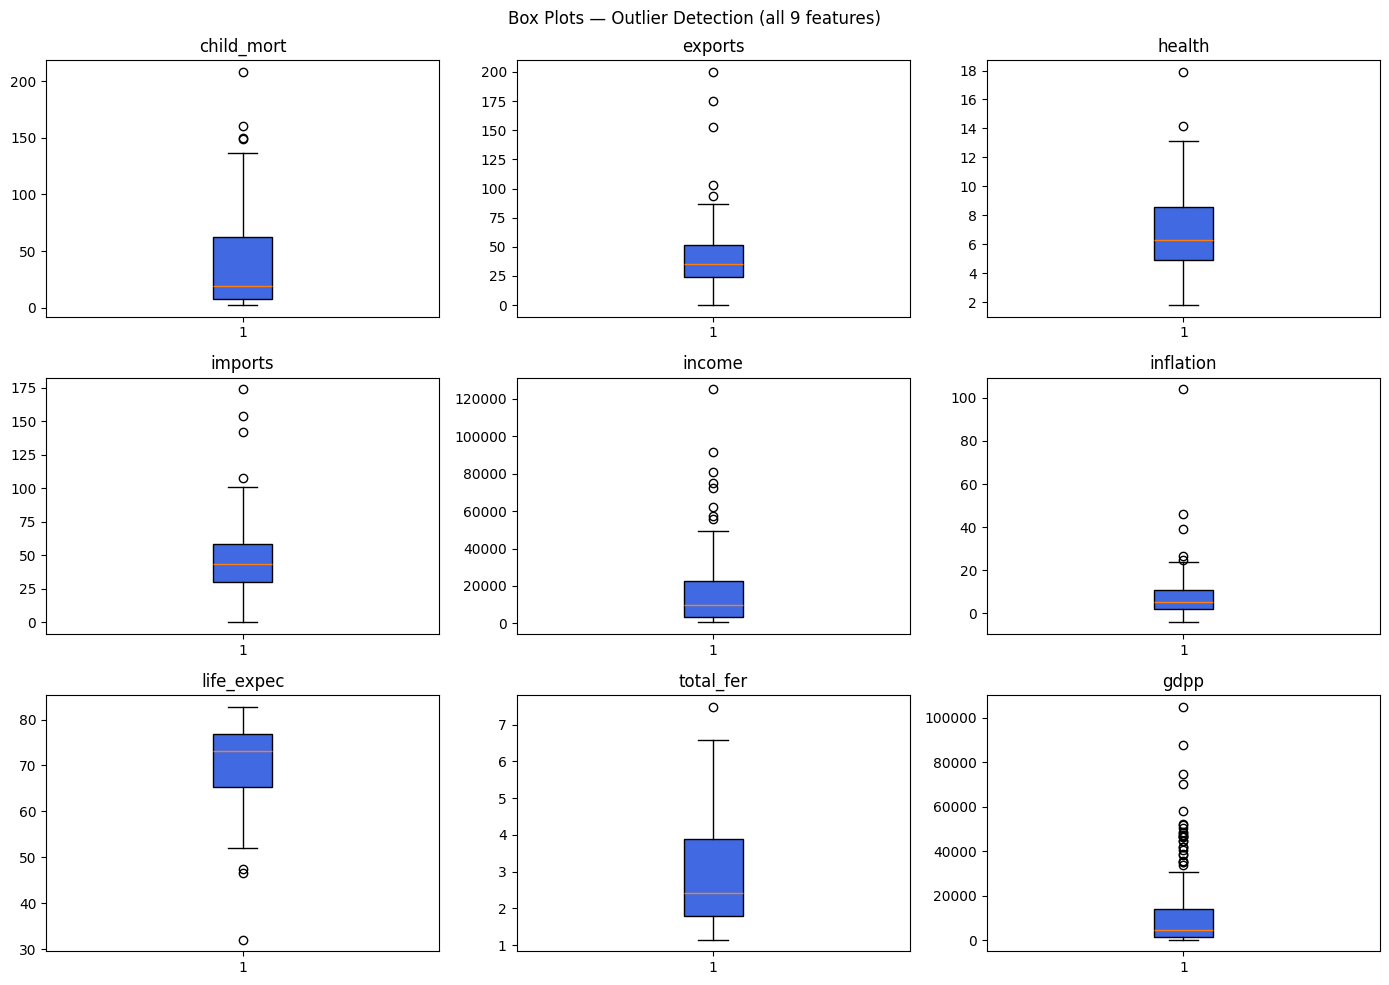

In [181]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col],
                    patch_artist=True,
                    boxprops=dict(facecolor="royalblue")
                    )
    axes[i].set_title(col)

plt.suptitle("Box Plots — Outlier Detection (all 9 features)")
plt.tight_layout()
plt.show()

We keep outliers — countries like Chad (high child_mort) or Luxembourg (high gdpp) are real data points, not errors.

Removing them would discard exactly the countries we need to identify.

*Examine the most extreme countries per key indicator*

In [182]:
print("Top 5 countries by Child Mortality")
print(df.nlargest(5, "child_mort")[["country", "child_mort", "gdpp", "income"]].to_string(index=False))

print("Top 5 countries by GDP per capita")
print(df.nlargest(5, "gdpp")[["country", "gdpp", "income", "life_expec"]].to_string(index=False))

print("Bottom 5 countries by Life Expectancy")
print(df.nsmallest(5, "life_expec")[["country", "life_expec", "child_mort", "gdpp"]].to_string(index=False))

Top 5 countries by Child Mortality
                 country  child_mort  gdpp  income
                   Haiti       208.0   662    1500
            Sierra Leone       160.0   399    1220
                    Chad       150.0   897    1930
Central African Republic       149.0   446     888
                    Mali       137.0   708    1870
Top 5 countries by GDP per capita
    country   gdpp  income  life_expec
 Luxembourg 105000   91700        81.3
     Norway  87800   62300        81.0
Switzerland  74600   55500        82.2
      Qatar  70300  125000        79.5
    Denmark  58000   44000        79.5
Bottom 5 countries by Life Expectancy
                 country  life_expec  child_mort  gdpp
                   Haiti        32.1       208.0   662
                 Lesotho        46.5        99.7  1170
Central African Republic        47.5       149.0   446
                  Zambia        52.0        83.1  1460
                  Malawi        53.1        90.5   459


*Correlation Analysis: This helps us identify which features move together and which are most important for clustering.*

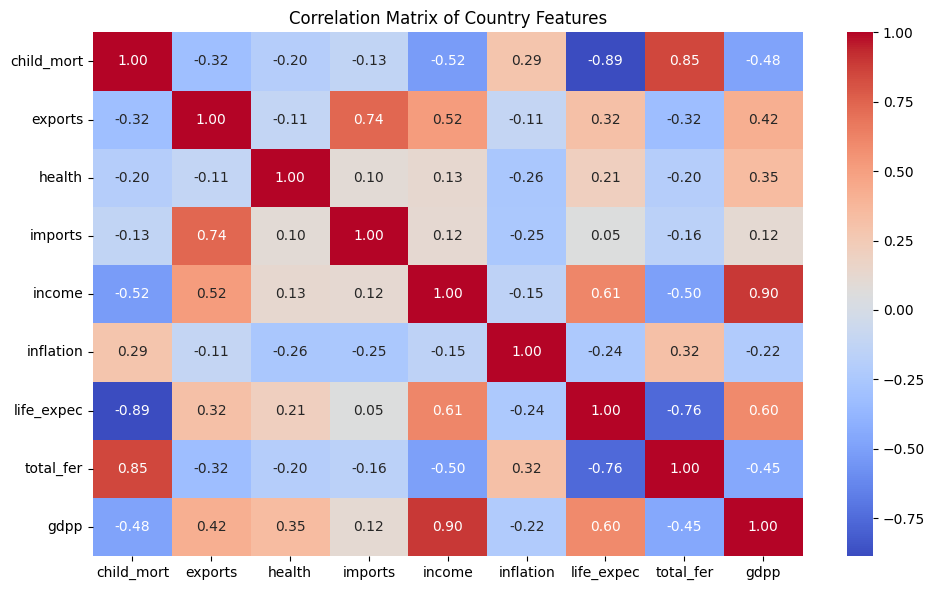

In [183]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop("country", axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Country Features")
plt.tight_layout()
plt.show()

*Scatter Plot for Child Mortality vs GDP per Capita*

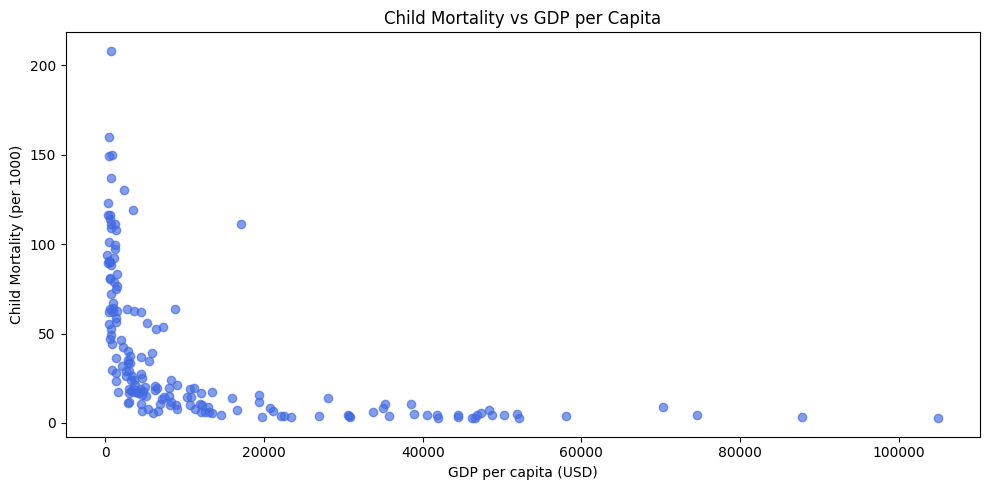

In [184]:
plt.figure(figsize=(10, 5))
plt.scatter(df["gdpp"], df["child_mort"], alpha = 0.65, color = "royalblue")
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Child Mortality (per 1000)")
plt.title("Child Mortality vs GDP per Capita")
plt.tight_layout()
plt.show()

*Scatter Plot for Income vs Life Expectancy*

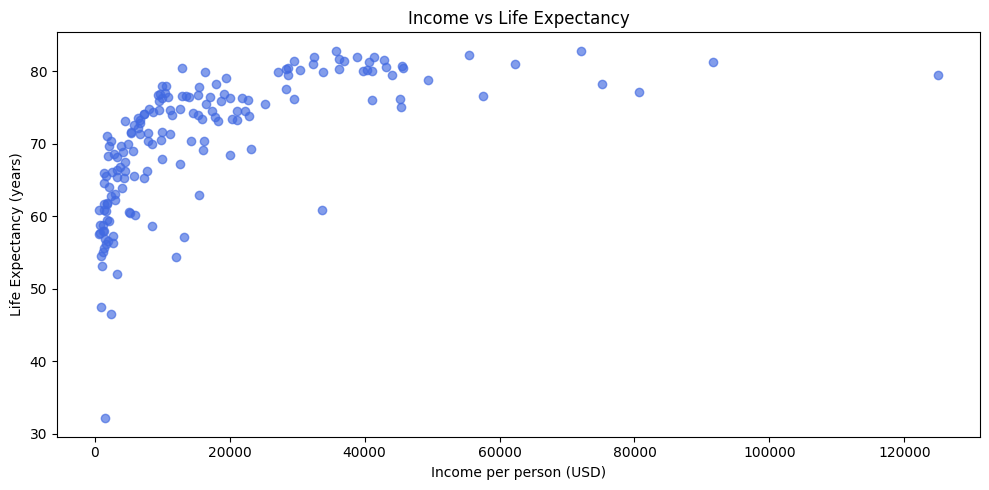

In [185]:
plt.figure(figsize=(10, 5))
plt.scatter(df['income'], df['life_expec'], alpha=0.65, color = "royalblue")
plt.xlabel("Income per person (USD)")
plt.ylabel("Life Expectancy (years)")
plt.title("Income vs Life Expectancy")
plt.tight_layout()
plt.show()

*Scatter Plot for Fertility Rate vs Child Mortality*

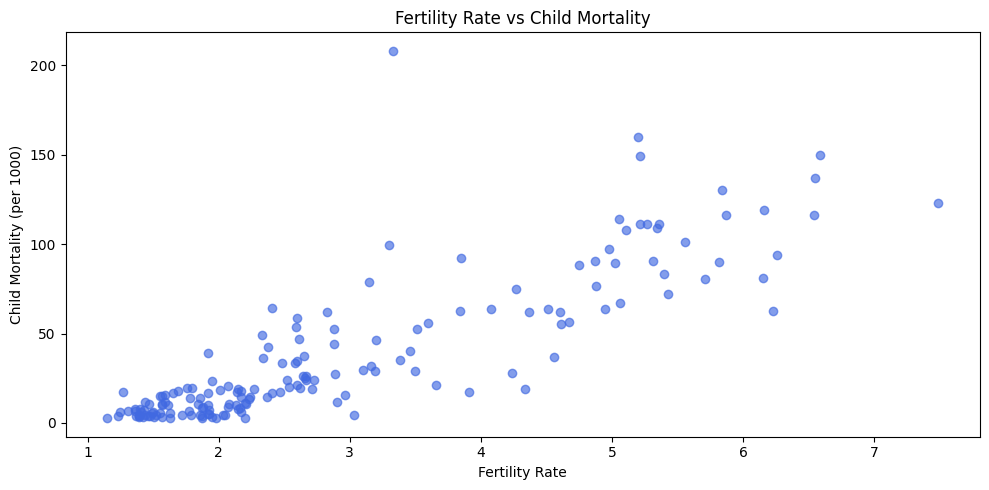

In [186]:
plt.figure(figsize=(10, 5))
plt.scatter(df["total_fer"], df["child_mort"], alpha=0.65, color = "royalblue")
plt.xlabel("Fertility Rate")
plt.ylabel("Child Mortality (per 1000)")
plt.title("Fertility Rate vs Child Mortality")
plt.tight_layout()
plt.show()

*Histplot for all 9 features with kde*

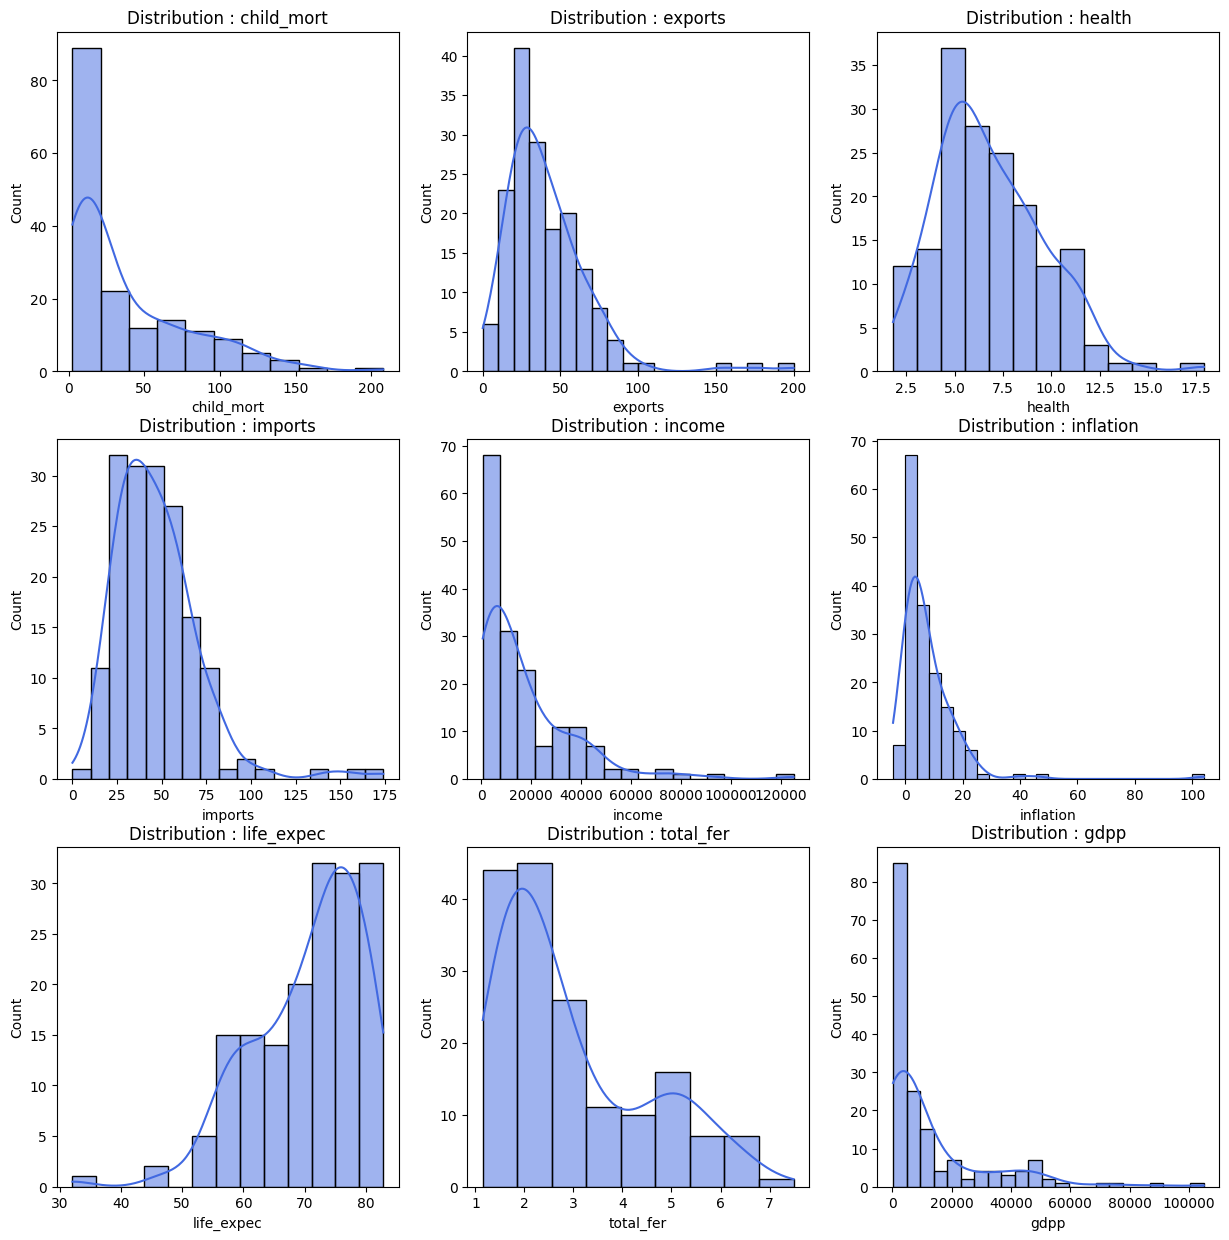

In [187]:
numerical_features = df.columns.drop("country")
fig, ax = plt.subplots(nrows = 3,ncols = 3,figsize = (15,15))
for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.histplot(
    df[numerical_features[i]],
    kde=True,
    color="royalblue"
)
    title = "Distribution : " + numerical_features[i]
    plt.title(title)
plt.show()

## Feature Scaling

K-Means uses Euclidean distance. Unscaled features like gdpp (0-105,000) would completely dominate health (1.8-17.9). Scaling puts all features on equal footing (mean=0, std=1).

In [188]:
countries = df["country"].values
X = df[features].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {features.tolist()}")

Feature matrix shape: (167, 9)
Features used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [189]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("After Scaling:")
print(X_scaled_df.describe().round(3))

After Scaling:
       child_mort  exports   health  imports   income  inflation  life_expec  \
count     167.000  167.000  167.000  167.000  167.000    167.000     167.000   
mean       -0.000    0.000    0.000    0.000   -0.000     -0.000       0.000   
std         1.003    1.003    1.003    1.003    1.003      1.003       1.003   
min        -0.887   -1.500   -1.828   -1.940   -0.860     -1.138      -4.337   
25%        -0.747   -0.633   -0.692   -0.691   -0.717     -0.567      -0.593   
50%        -0.472   -0.224   -0.181   -0.149   -0.374     -0.227       0.287   
75%         0.593    0.375    0.652    0.491    0.294      0.282       0.704   
max         4.221    5.814    4.047    5.266    5.612      9.130       1.381   

       total_fer     gdpp  
count    167.000  167.000  
mean       0.000    0.000  
std        1.003    1.003  
min       -1.191   -0.697  
25%       -0.764   -0.637  
50%       -0.356   -0.454  
75%        0.618    0.059  
max        3.009    5.037  


## K-Means Clustering

*Finding optimal value of K using Elbow method*

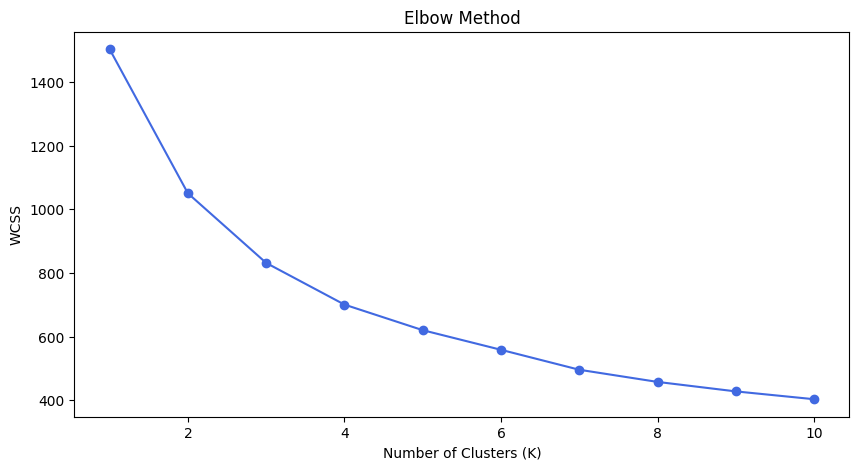

In [190]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker="o", color="royalblue")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Optimal value of K is found out to be K=3.

*Training K-Means Model*

In [191]:
km = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
df['kmeans_cluster'] = km.fit_predict(X_scaled)

print(f"K-Means trained with K=3")
print(f"Inertia (WCSS): {km.inertia_:.2f}")

K-Means trained with K=3
Inertia (WCSS): 831.42


*Cluster Profiling*

In [192]:
cluster_summary = df.groupby("kmeans_cluster").mean(numeric_only=True)
print(cluster_summary)

                child_mort    exports    health    imports        income  \
kmeans_cluster                                                             
0                 5.000000  58.738889  8.807778  51.491667  45672.222222   
1                92.961702  29.151277  6.388511  42.323404   3942.404255   
2                21.927381  40.243917  6.200952  47.473404  12305.595238   

                inflation  life_expec  total_fer          gdpp  
kmeans_cluster                                                  
0                2.671250   80.127778   1.752778  42494.444444  
1               12.019681   59.187234   5.008085   1922.382979  
2                7.600905   72.814286   2.307500   6486.452381  


In [193]:
print("Cluster sizes:")
print(df["kmeans_cluster"].value_counts().sort_index())

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


*Labeling Clusters*

In [194]:
cluster_names = {
    0: "Developed",
    1: "Underdeveloped",
    2: "Developing"
}

df["Country_Category"] = df["kmeans_cluster"].map(cluster_names)

print(df[["country", "kmeans_cluster", "Country_Category"]].head())

               country  kmeans_cluster Country_Category
0          Afghanistan               1   Underdeveloped
1              Albania               2       Developing
2              Algeria               2       Developing
3               Angola               1   Underdeveloped
4  Antigua and Barbuda               2       Developing


In [195]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,Country_Category
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,Underdeveloped
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,Developing
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,Developing
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,Underdeveloped
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,Developing


## DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) was applied to identify clusters based on data density.

In [196]:
dbs = DBSCAN(eps=1.5, min_samples=5)
df['DBScan_Cluster'] = dbs.fit_predict(X_scaled)

print(df['DBScan_Cluster'].value_counts())

DBScan_Cluster
 0    137
-1     30
Name: count, dtype: int64


*DBSCAN Cluster Analysis*

In [197]:
print("Number of DBSCAN Clusters:",
      len(set(df['DBScan_Cluster'])) - (1 if -1 in df['DBScan_Cluster'].values else 0))

print("Number of Noise Points:",
      list(df['DBScan_Cluster']).count(-1))

Number of DBSCAN Clusters: 1
Number of Noise Points: 30


*DBSCAN Hyperparameter Tuning*

In [198]:
for eps in [0.8, 1.0, 1.2, 1.4]:
    db = DBSCAN(eps=eps, min_samples=5)
    dbs_labels = db.fit_predict(X_scaled)

    n_clusters = len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)
    noise = list(dbs_labels).count(-1)

    print(f"epsilon = {eps} -> Clusters = {n_clusters}, Noise = {noise}")

epsilon = 0.8 -> Clusters = 3, Noise = 146
epsilon = 1.0 -> Clusters = 3, Noise = 94
epsilon = 1.2 -> Clusters = 3, Noise = 53
epsilon = 1.4 -> Clusters = 1, Noise = 40


In [199]:
for min_samples in [3, 4, 5]:
    db = DBSCAN(eps=1.2, min_samples=min_samples)
    dbs_labels = db.fit_predict(X_scaled)

    n_clusters = len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)
    noise = list(dbs_labels).count(-1)

    print(f"min_samples = {min_samples} -> Clusters = {n_clusters}, Noise = {noise}")

min_samples = 3 -> Clusters = 4, Noise = 41
min_samples = 4 -> Clusters = 3, Noise = 50
min_samples = 5 -> Clusters = 3, Noise = 53


*DBSCAN Clustering after parameter optimization*

In [200]:
dbs = DBSCAN(eps=1.2, min_samples=3)
df["DBScan_Cluster"] = dbs.fit_predict(X_scaled)
print(df["DBScan_Cluster"].value_counts())

DBScan_Cluster
 1    78
-1    41
 0    25
 2    19
 3     4
Name: count, dtype: int64


In [201]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,Country_Category,DBScan_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,Underdeveloped,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,Developing,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,Developing,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,Underdeveloped,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,Developing,1


## Classification and Ensemble Learning

*Train Test Split: Dataset was divided into training and testing data*

In [202]:
X = df.drop(["country", "kmeans_cluster", "Country_Category"], axis=1)
y = df["kmeans_cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (133, 10)
Testing Shape: (34, 10)


*Random Forest Classifier*

In [203]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



*XGBoost classifier*

In [204]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9705882352941176
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



## Model Comparison

In [205]:
rf_f1 = f1_score(y_test, y_pred, average='weighted')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print("Random Forest F1 Score :", round(rf_f1, 4))
print("XGBoost F1 Score       :", round(xgb_f1, 4))

if rf_f1 > xgb_f1:
    print("Random Forest performs better based on F1-score.")
else:
    print("XGBoost performs better based on F1-score.")

Random Forest F1 Score : 1.0
XGBoost F1 Score       : 0.9702
Random Forest performs better based on F1-score.


## Feature Importance Analysis

In [206]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

          Feature  Importance
0      child_mort    0.277779
6      life_expec    0.168815
8            gdpp    0.159257
4          income    0.141772
7       total_fer    0.138908
9  DBScan_Cluster    0.050581
2          health    0.027150
5       inflation    0.013425
3         imports    0.011259
1         exports    0.011053


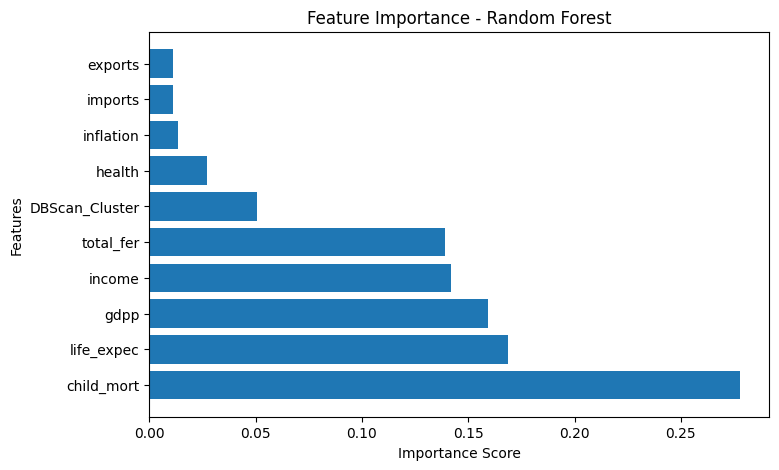

In [207]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Key Insights

1. **The dataset was clean and complete**, with no missing values or duplicate records, making it suitable for reliable clustering and classification analysis without extensive preprocessing.

2. **Strong relationships were observed between socio-economic indicators.** Countries with higher GDP per capita and income generally showed lower child mortality rates and higher life expectancy, indicating a strong link between economic prosperity and quality of life.

3. **Outliers represented meaningful real-world cases rather than data errors.** Countries with exceptionally high GDP (e.g., developed nations) or high child mortality and fertility rates (e.g., underdeveloped nations) provided valuable information for cluster formation and were therefore retained.

4. **K-Means clustering identified three distinct country groups:** Developed, Developing, and Underdeveloped. The Elbow Method indicated that **K = 3** was the optimal number of clusters for separating countries based on their socio-economic characteristics.

5. **Random Forest and XGBoost achieved very high classification performance** when predicting cluster membership, demonstrating that the generated clusters were well-defined. Feature importance analysis showed that indicators such as income, GDP per capita, child mortality, and life expectancy played a major role in distinguishing country categories.

## Conclusion

This project successfully developed a Country Intelligence System using exploratory data analysis, clustering, and machine learning techniques. After validating the quality of the dataset and performing extensive analysis, meaningful patterns were identified among economic, health, and demographic indicators. Correlation analysis and visualizations revealed clear relationships between national wealth, life expectancy, fertility rates, and child mortality.

K-Means clustering grouped countries into three meaningful categories: Developed, Developing, and Underdeveloped. The clustering results aligned well with real-world socio-economic conditions, demonstrating the effectiveness of unsupervised learning for country segmentation. DBSCAN was also explored as an alternative density-based clustering approach and provided additional insights into cluster structure and noise points.

Finally, Random Forest and XGBoost classifiers were trained to predict cluster membership. Both models achieved strong performance, confirming that the identified clusters were distinct and learnable. Overall, the project demonstrates how data science techniques can be used to transform raw country-level statistics into actionable insights for economic and developmental analysis.